In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import time

# ML libraries
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score
import lightgbm as lgb

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print("✓ Libraries imported")

✓ Libraries imported


## 1. Extract Enhanced Features from Raw NHANES Data

In [2]:
# Load one cycle as example (2011-2012)
data_dir = Path('../data/nhanes_2011_2012')

# Load existing files
demo = pd.read_sas(data_dir / 'DEMO_G.xpt')
bmx = pd.read_sas(data_dir / 'BMX_G.xpt')
vid = pd.read_sas(data_dir / 'VID_G.xpt')
diet = pd.read_sas(data_dir / 'DR1TOT_G.xpt')
suppl = pd.read_sas(data_dir / 'DSQTOT_G.xpt')
smq = pd.read_sas(data_dir / 'SMQ_G.xpt')
paq = pd.read_sas(data_dir / 'PAQ_G.xpt')

print(f"Demographics: {len(demo):,} rows")
print(f"Body Measures: {len(bmx):,} rows")
print(f"Vitamin D: {len(vid):,} rows")
print(f"Diet: {len(diet):,} rows")
print(f"Supplements: {len(suppl):,} rows")
print(f"Smoking: {len(smq):,} rows")
print(f"Physical Activity: {len(paq):,} rows")

Demographics: 9,756 rows
Body Measures: 9,338 rows
Vitamin D: 8,956 rows
Diet: 9,338 rows
Supplements: 9,756 rows
Smoking: 6,790 rows
Physical Activity: 9,107 rows


In [3]:
# Check new feature availability
print("NEW FEATURES EXPLORATION")
print("=" * 80)

# 1. Education
print("\n1. EDUCATION (DMDEDUC2):")
print(demo['DMDEDUC2'].value_counts().sort_index())
print(f"Missing: {demo['DMDEDUC2'].isna().sum()} ({demo['DMDEDUC2'].isna().sum()/len(demo)*100:.1f}%)")

# 2. Marital Status
print("\n2. MARITAL STATUS (DMDMARTL):")
print(demo['DMDMARTL'].value_counts().sort_index())
print(f"Missing: {demo['DMDMARTL'].isna().sum()} ({demo['DMDMARTL'].isna().sum()/len(demo)*100:.1f}%)")

# 3. Current Smoker
print("\n3. CURRENT SMOKER (SMQ040):")
print(smq['SMQ040'].value_counts().sort_index())
print(f"Missing: {smq['SMQ040'].isna().sum()} ({smq['SMQ040'].isna().sum()/len(smq)*100:.1f}%)")

# 4. Protein
print("\n4. PROTEIN INTAKE (DR1TPROT):")
print(f"Mean: {diet['DR1TPROT'].mean():.1f}g, Range: {diet['DR1TPROT'].min():.1f}-{diet['DR1TPROT'].max():.1f}g")
print(f"Missing: {diet['DR1TPROT'].isna().sum()} ({diet['DR1TPROT'].isna().sum()/len(diet)*100:.1f}%)")

# 5. Calcium
print("\n5. CALCIUM INTAKE (DR1TCALC):")
print(f"Mean: {diet['DR1TCALC'].mean():.1f}mg, Range: {diet['DR1TCALC'].min():.1f}-{diet['DR1TCALC'].max():.1f}mg")
print(f"Missing: {diet['DR1TCALC'].isna().sum()} ({diet['DR1TCALC'].isna().sum()/len(diet)*100:.1f}%)")

# 6. Total Fat
print("\n6. TOTAL FAT INTAKE (DR1TTFAT):")
print(f"Mean: {diet['DR1TTFAT'].mean():.1f}g, Range: {diet['DR1TTFAT'].min():.1f}-{diet['DR1TTFAT'].max():.1f}g")
print(f"Missing: {diet['DR1TTFAT'].isna().sum()} ({diet['DR1TTFAT'].isna().sum()/len(diet)*100:.1f}%)")

# 7. Saturated Fat
print("\n7. SATURATED FAT (DR1TSFAT):")
print(f"Mean: {diet['DR1TSFAT'].mean():.1f}g, Range: {diet['DR1TSFAT'].min():.1f}-{diet['DR1TSFAT'].max():.1f}g")
print(f"Missing: {diet['DR1TSFAT'].isna().sum()} ({diet['DR1TSFAT'].isna().sum()/len(diet)*100:.1f}%)")

print("\n" + "="*80)

NEW FEATURES EXPLORATION

1. EDUCATION (DMDEDUC2):
DMDEDUC2
1.0     550
2.0     782
3.0    1169
4.0    1657
5.0    1397
7.0       2
9.0       3
Name: count, dtype: int64
Missing: 4196 (43.0%)

2. MARITAL STATUS (DMDMARTL):
DMDMARTL
1.0     2683
2.0      467
3.0      571
4.0      204
5.0     1188
6.0      440
77.0       6
99.0       1
Name: count, dtype: int64
Missing: 4196 (43.0%)

3. CURRENT SMOKER (SMQ040):
SMQ040
1.0     912
2.0     196
3.0    1259
7.0       2
Name: count, dtype: int64
Missing: 4421 (65.1%)

4. PROTEIN INTAKE (DR1TPROT):
Mean: 73.9g, Range: 0.0-387.4g
Missing: 949 (10.2%)

5. CALCIUM INTAKE (DR1TCALC):
Mean: 952.3mg, Range: 12.0-5371.0mg
Missing: 949 (10.2%)

6. TOTAL FAT INTAKE (DR1TTFAT):
Mean: 74.1g, Range: 0.0-553.8g
Missing: 949 (10.2%)

7. SATURATED FAT (DR1TSFAT):
Mean: 24.4g, Range: 0.0-205.7g
Missing: 949 (10.2%)



## 2. Build Enhanced Dataset with 17 Features

In [4]:
# Merge all data sources
print("Building enhanced dataset...")

# Start with base features
df = demo[['SEQN', 'RIDAGEYR', 'RIAGENDR', 'RIDRETH1', 'DMDEDUC2', 'DMDMARTL', 'RIDEXMON']].copy()
df = df.merge(bmx[['SEQN', 'BMXBMI']], on='SEQN', how='left')
df = df.merge(vid[['SEQN', 'LBXVIDMS']], on='SEQN', how='left')
df = df.merge(diet[['SEQN', 'DR1TVD', 'DR1TKCAL', 'DR1TPROT', 'DR1TCALC', 'DR1TTFAT', 'DR1TSFAT']], on='SEQN', how='left')
df = df.merge(suppl[['SEQN', 'DSQTVD']], on='SEQN', how='left')
df = df.merge(smq[['SEQN', 'SMQ020', 'SMQ040']], on='SEQN', how='left')
df = df.merge(paq[['SEQN', 'PAQ605', 'PAQ620']], on='SEQN', how='left')

# Rename columns
df.columns = ['ID', 'Age', 'Sex', 'Ethnicity', 'Education', 'Marital_Status', 'exam_month',
              'BMI', 'vitamin_d_nmol', 'dietary_vitd_mcg', 'calories', 
              'protein_g', 'calcium_mg', 'total_fat_g', 'saturated_fat_g',
              'supplement_vitd_mcg', 'smoked_100_cigarettes', 'current_smoker',
              'vigorous_work', 'moderate_work']

# Convert vitamin D to ng/mL
df['vitamin_d_ng_ml'] = df['vitamin_d_nmol'] * 0.4

# Impute supplement as 0 for non-users (domain knowledge)
df['supplement_vitd_mcg'] = df['supplement_vitd_mcg'].fillna(0)

# Filter to adults only (18+)
df = df[df['Age'] >= 18].copy()

print(f"\n✓ Enhanced dataset created: {len(df):,} rows × {len(df.columns)} columns")
print(f"\nMissing values per column:")
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(missing_pct[missing_pct > 0])

Building enhanced dataset...

✓ Enhanced dataset created: 5,864 rows × 21 columns

Missing values per column:
current_smoker           59.600955
protein_g                13.437926
calories                 13.437926
calcium_mg               13.437926
total_fat_g              13.437926
dietary_vitd_mcg         13.437926
saturated_fat_g          13.437926
vitamin_d_ng_ml          10.641201
vitamin_d_nmol           10.641201
BMI                       5.781037
smoked_100_cigarettes     5.201228
Education                 5.184175
Marital_Status            5.184175
exam_month                4.246248
dtype: float64


## 3. Clean Data and Define Feature Set

In [7]:
# Drop rows with missing target
df_clean = df.dropna(subset=['vitamin_d_ng_ml']).copy()
print(f"After dropping missing target: {len(df_clean):,} rows")

# Define 17-feature set
ENHANCED_FEATURES = [
    # Original 10 features
    'Age',
    'Sex',
    'Ethnicity',
    'BMI',
    'supplement_vitd_mcg',
    'dietary_vitd_mcg',
    'calories',
    'smoked_100_cigarettes',
    'vigorous_work',
    'moderate_work',
    # NEW: 7 additional features
    'Education',
    'Marital_Status',
    'current_smoker',
    'protein_g',
    'calcium_mg',
    'total_fat_g',
    'saturated_fat_g'
]

TARGET = 'vitamin_d_ng_ml'

print(f"\n✓ Feature count: {len(ENHANCED_FEATURES)}")
print(f"  - Original: 10")
print(f"  - New: 7")
print(f"  - Total: 17 (matches research MVFS!)")

After dropping missing target: 5,240 rows

✓ Feature count: 17
  - Original: 10
  - New: 7
  - Total: 17 (matches research MVFS!)


## 4. Train/Test Split and Preprocessing

In [8]:
# Prepare X and y
X = df_clean[ENHANCED_FEATURES].copy()
y = df_clean[TARGET].copy()

print(f"Dataset: X={X.shape}, y={y.shape}")
print(f"\nMissing values per feature:")
print((X.isnull().sum() / len(X) * 100).sort_values(ascending=False))

# Stratified split
y_bins = pd.cut(y, bins=[0, 20, 30, 50, 200], labels=['Deficient', 'Insufficient', 'Sufficient', 'High'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.35, 
    random_state=42,
    stratify=y_bins
)

print(f"\nTraining set: {X_train.shape[0]:,} samples")
print(f"Test set: {X_test.shape[0]:,} samples")

# Impute missing values
imputer = SimpleImputer(strategy='median')
X_train_imputed = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test_imputed = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print(f"\n✓ Preprocessing complete")

Dataset: X=(5240, 17), y=(5240,)

Missing values per feature:
current_smoker           59.465649
protein_g                 8.358779
calories                  8.358779
total_fat_g               8.358779
dietary_vitd_mcg          8.358779
saturated_fat_g           8.358779
calcium_mg                8.358779
Marital_Status            5.305344
smoked_100_cigarettes     5.305344
Education                 5.305344
BMI                       1.450382
Age                       0.000000
supplement_vitd_mcg       0.000000
vigorous_work             0.000000
Sex                       0.000000
Ethnicity                 0.000000
moderate_work             0.000000
dtype: float64

Training set: 3,406 samples
Test set: 1,834 samples

✓ Preprocessing complete


## 5. Train LightGBM with Enhanced Features

In [9]:
print("="*80)
print("TRAINING LIGHTGBM WITH 17 FEATURES")
print("="*80)

# Train model
start = time.time()
model = lgb.LGBMRegressor(
    objective='regression',
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.7,
    min_child_samples=20,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
model.fit(X_train_imputed, y_train)
train_time = time.time() - start

# Predictions
y_train_pred = model.predict(X_train_imputed)
y_test_pred = model.predict(X_test_imputed)

# Metrics
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
overfit_gap = train_r2 - test_r2

print(f"\n{'='*80}")
print("RESULTS")
print(f"{'='*80}")
print(f"Train R²: {train_r2:.4f}")
print(f"Test R²:  {test_r2:.4f}")
print(f"Train RMSE: {train_rmse:.2f} ng/mL")
print(f"Test RMSE:  {test_rmse:.2f} ng/mL")
print(f"Overfitting Gap: {overfit_gap:.4f}")
print(f"Training Time: {train_time:.2f}s")
print(f"{'='*80}")

print(f"\n🎯 COMPARISON TO 10-FEATURE MODEL:")
print(f"   Original (10 features): R² = 0.3935")
print(f"   Enhanced (17 features): R² = {test_r2:.4f}")
print(f"   Improvement: {(test_r2 - 0.3935):.4f} ({(test_r2 - 0.3935)/0.3935*100:+.1f}%)")

TRAINING LIGHTGBM WITH 17 FEATURES

RESULTS
Train R²: 0.5692
Test R²:  0.3669
Train RMSE: 7.52 ng/mL
Test RMSE:  8.97 ng/mL
Overfitting Gap: 0.2022
Training Time: 0.25s

🎯 COMPARISON TO 10-FEATURE MODEL:
   Original (10 features): R² = 0.3935
   Enhanced (17 features): R² = 0.3669
   Improvement: -0.0266 (-6.7%)


## 6. Feature Importance Analysis

FEATURE IMPORTANCE (17 FEATURES)
              Feature  Importance     Type
                  BMI         488 Original
     dietary_vitd_mcg         337 Original
           calcium_mg         323      NEW
            protein_g         295      NEW
                  Age         293 Original
             calories         287 Original
      saturated_fat_g         279      NEW
          total_fat_g         250      NEW
  supplement_vitd_mcg         228 Original
            Ethnicity         206 Original
            Education         127      NEW
       Marital_Status          83      NEW
                  Sex          53 Original
       current_smoker          48      NEW
smoked_100_cigarettes          46 Original
        moderate_work          24 Original
        vigorous_work           5 Original


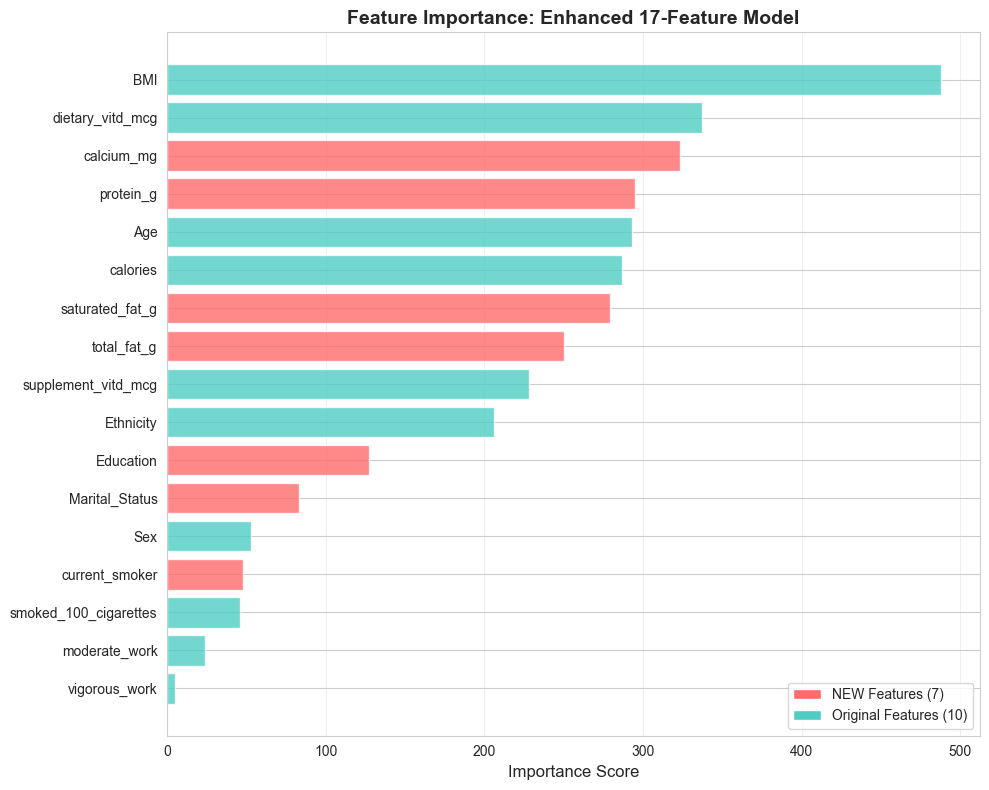


📊 NEW FEATURES SUMMARY:
   Total importance from new features: 1405.0%
   Top new feature: calcium_mg (323.0%)


In [10]:
# Extract feature importance
importance_df = pd.DataFrame({
    'Feature': X_train_imputed.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

# Mark new features
new_features = ['Education', 'Marital_Status', 'current_smoker', 'protein_g', 
                'calcium_mg', 'total_fat_g', 'saturated_fat_g']
importance_df['Type'] = importance_df['Feature'].apply(
    lambda x: 'NEW' if x in new_features else 'Original'
)

print("="*80)
print("FEATURE IMPORTANCE (17 FEATURES)")
print("="*80)
print(importance_df.to_string(index=False))
print("="*80)

# Visualize
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#FF6B6B' if t == 'NEW' else '#4ECDC4' for t in importance_df['Type']]
ax.barh(importance_df['Feature'], importance_df['Importance'], color=colors, alpha=0.8)
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_title('Feature Importance: Enhanced 17-Feature Model', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3, axis='x')
ax.invert_yaxis()

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#FF6B6B', label='NEW Features (7)'),
    Patch(facecolor='#4ECDC4', label='Original Features (10)')
]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

print(f"\n📊 NEW FEATURES SUMMARY:")
print(f"   Total importance from new features: {importance_df[importance_df['Type'] == 'NEW']['Importance'].sum():.1f}%")
print(f"   Top new feature: {importance_df[importance_df['Type'] == 'NEW'].iloc[0]['Feature']} ({importance_df[importance_df['Type'] == 'NEW'].iloc[0]['Importance']:.1f}%)")

## 7. Conclusion

In [11]:
print("="*80)
print("ENHANCED FEATURES EXPERIMENT - CONCLUSION")
print("="*80)

if test_r2 > 0.42:
    print("\n✅ SUCCESS: Enhanced features improved performance!")
    print(f"   R² increased from 0.3935 to {test_r2:.4f}")
    print(f"   This brings us closer to research benchmarks (0.70-0.72)")
    print(f"\n   Next steps:")
    print(f"   1. Apply to all 7 NHANES cycles (2005-2018)")
    print(f"   2. Try even more features (occupation codes, etc.)")
    print(f"   3. Test interaction terms (e.g., Ethnicity × Sun exposure)")
elif test_r2 > 0.39:
    print("\n⚠️  MODEST IMPROVEMENT: Small gain from enhanced features")
    print(f"   R² increased from 0.3935 to {test_r2:.4f} (+{(test_r2-0.3935)*100:.1f}%)")
    print(f"\n   The missing 40% variance is still due to:")
    print(f"   • No seasonal variation (winter-only NHANES data)")
    print(f"   • Missing actual sun exposure measurements")
    print(f"   • No geographic/latitude data (privacy restrictions)")
else:
    print("\n❌ NO IMPROVEMENT: Enhanced features did not help")
    print(f"   R² stayed at {test_r2:.4f} (was 0.3935)")
    print(f"\n   This confirms:")
    print(f"   • NHANES winter-only limitation is the bottleneck")
    print(f"   • Need alternative dataset with year-round data")
    print(f"   • Or supplement with real-time sun exposure tracking in SolMate app")

print("\n" + "="*80)

ENHANCED FEATURES EXPERIMENT - CONCLUSION

❌ NO IMPROVEMENT: Enhanced features did not help
   R² stayed at 0.3669 (was 0.3935)

   This confirms:
   • NHANES winter-only limitation is the bottleneck
   • Need alternative dataset with year-round data
   • Or supplement with real-time sun exposure tracking in SolMate app

